# Load data

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import collections
import pandas as pd
import seaborn as sns

import config, dataloader
import nb_utils
import latex_utils

config = {
    # "assistant_models": ["olmo2-7b-instruct", "olmo2-13b-instruct", "olmo3-7b-instruct", "qwen3-8b", "qwen3-14b",  "gemini-2.5-flash"],
    "assistant_models": ["olmo2-7b-instruct", "olmo2-13b-instruct", "olmo3-7b-instruct", "qwen3-8b", "qwen3-14b", "gemini-2.5-flash"],
    "direct_prompts": ["vanilla", "concise", "sentence"],
    "belief_samplings": ["unbiased"],
    "reasoner_prompts": ["prompt", "belief", "belief6", "belief7"],
    "final_prompts": ["prompt", "prompt1", "belief"],
    "steps": ["direct", "disambiguated", "reasoner", "user", "final"],
    "user_model": "gemini-2.5-flash",
    "seed": 50,
    "filter_evergreen": False,
    "judge_model": "gemini-2.5-flash",  # set to None to skip judge metrics
    "max_examples": 2000,  # set to None to load all examples
    "split": "dev",
}

# outputs[assistant_model][direct_prompt][belief_sampling][pipeline_step][reasoner_prompt (optional)]
outputs = dataloader.load_pipeline_output(**config)

In [10]:
# Check all generation output files have the same length and aligned question IDs.
# nb_utils.check_output_completeness(outputs)

In [11]:
# Check that all generation step outputs (e.g., disambig oracle, user simulation and final) used the same AmbigQA reference answer for fair comparison
# nb_utils.check_ref_consistency(outputs)
# nb_utils.check_direct_judge_ref_consistency(outputs, config)

# Length/truncation analysis

In [12]:
brevity      = "vanilla"
split_belief = True  # True: one violin per belief prompt; False: collapse all belief into one
split_final = True

# nb_utils.plot_length_distributions(outputs, config, brevity=brevity, split_belief=split_belief)
# nb_utils.print_truncation_rates(outputs, config, brevity=brevity)

# Visualise strategy distribution

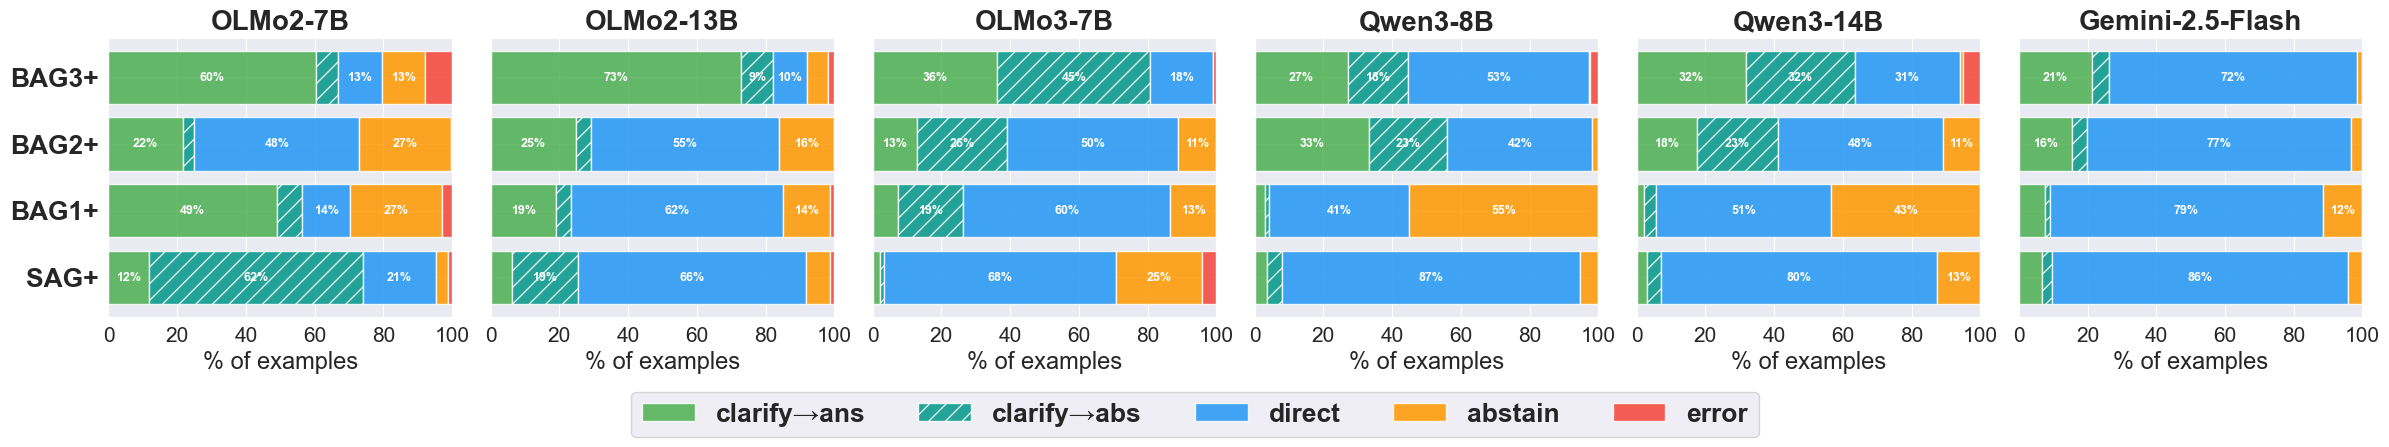

In [8]:
final_prompt  = "+"
nb_utils.plot_strategy_distribution(outputs, config, final_prompt=final_prompt, brevities=["vanilla"])

# Quantify pipeline errors

In [13]:

# How often does the user simulator give away the answer?
# user %              — user answer contains ref / total responses
# user & !cq | flip % — user answer contains ref & CQ doesn't & interaction improves final answer (flip) / total improvements (flips)
# user_errors %       — user entries with no response / n_user_entries
# missing_user %      — clarify examples with no user entry / n_clarified
# missing_final %     — user entries with no final output / n_user_entries
# nb_utils.pipeline_error_summary(outputs, config, collapse=None)

# Main paper results
## Table 1

In [14]:
from nb_utils import build_and_display_metrics_tables
import evaluation_utils

metrics = nb_utils.nested_dict()

do_print='none' # choose from: direct, disambig, reasoner.direct, final
# outputs[assistant_model][direct_prompt][pipeline_step][reasoner_prompt (optional)]
for assistant_model in config['assistant_models']:
    for direct_prompt in config['direct_prompts']:
        for belief_sampling in config['belief_samplings']:
            for reasoner_prompt in config['reasoner_prompts']:
                o = outputs[assistant_model][direct_prompt][belief_sampling]

                valid = [i for i, d in enumerate(o["direct"]) if nb_utils.sample_is_valid(d)]
                n_skipped = len(o["direct"]) - len(valid)
                if n_skipped:
                    print(f"Skipped {n_skipped} parse errors for {assistant_model}/{direct_prompt}/{belief_sampling}/{reasoner_prompt}")

                def _filter(lst):
                    if lst is None:
                        return None
                    return [lst[i] for i in valid]

                is_belief_reasoner = "belief" in reasoner_prompt
                applicable_final_prompts = [
                    fp for fp in config.get('final_prompts', ['prompt'])
                    if fp == "prompt" or ("belief" in fp) == is_belief_reasoner
                ]
                for final_prompt in applicable_final_prompts:
                    final_items_raw = (o.get("final") or {}).get(reasoner_prompt, {}).get(final_prompt)
                    if final_items_raw is None:
                        continue
                    final_judge_raw = (o.get("final_judge") or {}).get(reasoner_prompt, {}).get(final_prompt)
                    n_direct = len(o["direct"])
                    output = {
                        "direct":        _filter(o["direct"]),
                        "disambiguated": _filter(o["disambiguated"]),
                        "reasoner":      _filter(o["reasoner"][reasoner_prompt]),
                        "user":          _filter(o["user"][reasoner_prompt]),
                        "final":         _filter(final_items_raw),
                        "direct_judge":   _filter(o.get("direct_judge")),
                        "disambig_judge": _filter(o.get("disambig_judge")),
                        "belief_judge":   None,  # _filter(o.get("belief_judge")) — stale (old dataset size)
                        "clarify_judge":  _filter((o.get("clarify_judge") or {}).get(reasoner_prompt)),
                        "final_judge":    _filter(final_judge_raw if final_judge_raw else [None] * n_direct),
                    }
                    metrics[assistant_model][direct_prompt][belief_sampling][reasoner_prompt][final_prompt] = evaluation_utils.compute_metrics(output, do_print=do_print, skip_rouge=True)


metric_type = "judge"  # "rouge" or "judge"
ref_type    = "1"
gradient_by = "row"  # "global" or "model"
direct_prompt = None
final_variant = "+"  # "all", "+", or "prompt"
build_and_display_metrics_tables(metrics, config, metric_type, ref_type, gradient_by=gradient_by, direct_prompt=direct_prompt, final_variant=final_variant,  include_words_col=True)

# two_col     = True     # True = table* (two-col); False = table (one-col, footnotesize)
# _ = latex_utils.pipeline_results_to_latex(metrics, config, metric_type, ref_type, gradient_by=gradient_by, two_col=two_col, direct_prompt=direct_prompt, final_variant=final_variant,  include_words_col=True)

# Routing profile and clarification effectiveness

**Block 1 — Routing profile**: for each prompt, what fraction of examples go to each branch,
how hard are those subsets (direct-answer judge baseline), and how many are actually ambiguous?

**Block 2 — Clarification effectiveness**: conditioned on having clarified, what fraction of
wrong-baseline examples are rescued (recovery rate) and what fraction of right-baseline examples
regress (regression rate)? Recovery rate is the cleanest measure of CQ quality — it is bottlenecked
by model knowledge, not by routing.

In [18]:
routing_direct_prompt = "vanilla"  # set here to control which direct_prompt is shown
routing_metric_type   = "judge"  # "rouge" or "judge"
ref_type             = "1"      # "1" or "any"

settings = None
nb_utils.plot_routing_profile(metrics, config, routing_metric_type, routing_direct_prompt, ref_type=ref_type, settings=settings, block1_cols=('quality', 'ambig'), gradient_by="row", avg_bag_variants=True)
# _ = latex_utils.routing_profile_to_latex(metrics, config, routing_metric_type, ref_type=ref_type, settings=settings, block1_cols=('quality', 'ambig'),
# gradient_by="row", direct_prompt=routing_direct_prompt, avg_bag_variants=True)

In [19]:
# routing_direct_prompt = "concise"  # set here to control which direct_prompt is shown
# routing_metric_type   = "judge"  # "rouge" or "judge"
# ref_type             = "1"      # "1" or "any"
# routing_final_prompt  = "+"  # set here to control which final_prompt (prompt or +)
# settings=None
# nb_utils.plot_clarify_effectiveness(metrics, config, routing_metric_type, routing_direct_prompt, ref_type=ref_type, final_prompt=routing_final_prompt, settings=settings)
# _ = nb_utils.clarify_effectiveness_to_latex(metrics, config, routing_metric_type, ref_type=ref_type, gradient_by="global", direct_prompt=routing_direct_prompt, final_prompt=routing_final_prompt, settings=settings)
# nb_utils.plot_flip_distribution(metrics, config, routing_metric_type, routing_direct_prompt, ref_type=ref_type, final_prompt=routing_final_prompt, compact=True)

## Intent recovery: ambiguous + clarify subset

On examples that are (a) genuinely ambiguous and (b) routed to clarify, the direct
answer must guess the user's specific interpretation. The interactive pipeline learns
it via CQ. Comparing final vs direct on this subset isolates the value of interaction
for intent recovery, independent of routing or abstain effects.

- **direct (1 ref)**: strict — may miss the user's intended interpretation
- **direct (any ref)**: lenient upper bound — does the model know *any* interpretation?
- **disambig oracle**: ceiling — given the right disambiguation as input
- **final (after CQ)**: the pipeline score — did interaction recover the specific intent?
- **Δ vs any ref**: key test — does the pipeline beat a model that already knows something?

In [20]:
# nb_utils.plot_intent_recovery(metrics, config, metric_type, routing_direct_prompt)

## Block 3 — Cross-prompt comparison on shared clarified examples

For each pair of prompts (row, col), the cell shows the **row prompt's final_judge score**
evaluated only on examples that **both** prompts clarified. This holds routing constant:
if row scores higher than col in the same column, its CQ quality is genuinely better on
those questions — not just because it routes to easier examples.

Read column-wise: all entries in a column are evaluated on the same subset of questions.
The diagonal is each prompt's score on its own full clarified set.

In [10]:
# nb_utils.plot_cross_prompt_comparison(metrics, config, routing_metric_type, routing_direct_prompt)

## Decomposition: routing/selection gain vs within-branch gain

The total gap visible in the summary table splits cleanly into three parts:

```
Δtotal = routing_gain + within_clarify + within_direct

routing_gain   = mean(baseline for n_c+n_d subset) − mean(baseline for all N)
within_clarify = (n_c / (n_c+n_d)) × mean(full_interactive − full_baseline)  for clarify examples
within_direct  = (n_d / (n_c+n_d)) × mean(full_interactive − full_baseline)  for direct examples
```

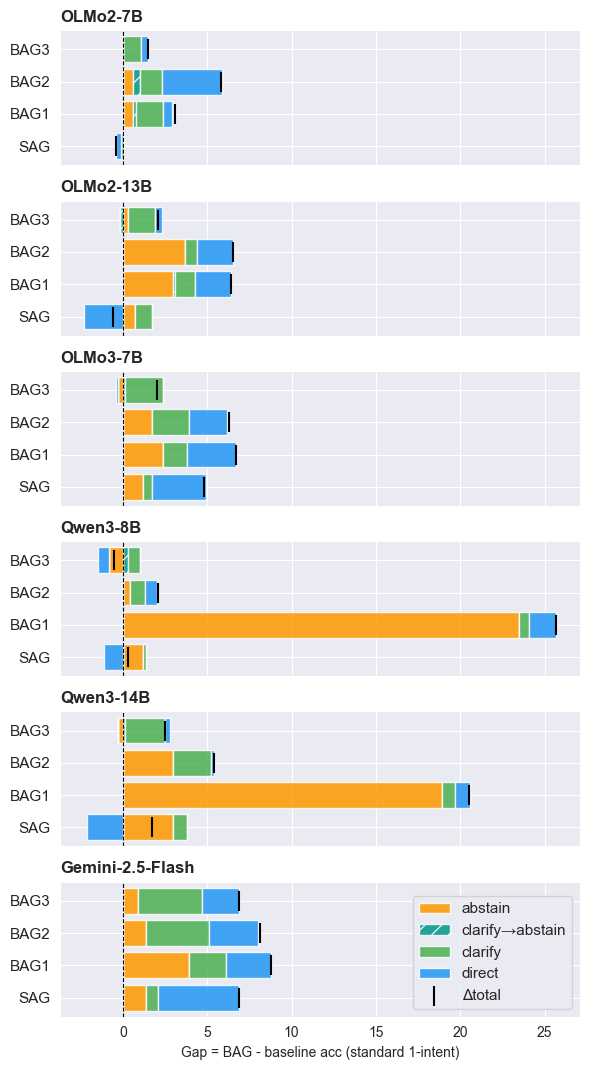

In [21]:
ref_type = "1"      # "1" or "any"

settings = (
    ("olmo2-7b-instruct", "vanilla"),
    ("olmo2-13b-instruct", "vanilla"),
    ("olmo3-7b-instruct", "vanilla"),
    ("qwen3-8b", "vanilla"),
    ("qwen3-14b", "vanilla"),
    ("gemini-2.5-flash", "vanilla"),
)

variant = "prompt"  # "all", "+", or "prompt"
nb_utils.plot_routing_decomposition(metrics, config, metric_type, ref_type=ref_type, settings=settings, show_labels=False, variant=variant)

# Qualitative trace viewer

Prints full pipeline traces for selected examples.

**Filter options** (set in the config block below):
- `filter_strategy`: `"all"` | `"clarification_question"` | `"direct_answer"` | `"abstain"`
- `filter_disambig_flip`: only show examples where direct was *wrong* and final was *correct* (recovery)
- `filter_clarification_flip`: only show examples where direct was *right* and final was *wrong* (regression)
- `filter_ambiguous_only`: only examples that have at least one disambiguation

Flip filters use `direct_judge` (1-ref) vs `final_judge`. They only apply to clarification examples.

In [12]:
# ── Configuration ─────────────────────────────────────────────────────────────
trace_config = dict(
    model            = "gemini-2.5-flash",
    reasoner_prompt  = "belief6",
    direct_prompt    = "vanilla",
    belief_sampling  = "unbiased",
    final_prompt     = "prompt",
    n_traces         = 10,
    filter_strategy  = "clarification_question",  # "all" | "clarification_question" | "direct_answer" | "abstain"
    filter_ambiguous_only = False,
    show_belief      = False,
)
named_filters = {'pos': 'reasoner_direct_pos', 'neg': 'reasoner_direct_neg'}
# ──────────────────────────────────────────────────────────────────────────────

nb_utils.run_trace_viewer(outputs, metrics, trace_config, named_filters)

Setting : gemini-2.5-flash | belief6 | vanilla | unbiased
Filters : pos=10, neg=10
Showing : 20 trace(s)


##########################################################################################
## POS  (10 example(s))
##########################################################################################

>>> POS <<<
[idx=5]  strategy=direct_answer  n_disambigs=2
JUDGES : direct=0  direct_any=0  belief=1  final=None  disambig=1  reason_direct=1

QUESTION:
  When was memorial day declared a national holiday?

DISAMBIGUATIONS:
  - {'question': 'When was the act signed that made Memorial Day a national holiday?', 'answer': ['June 18, 1968'], 'annotation_index': 0}
  - {'question': 'When did the law go into effect, making Memorial Day a national holiday?', 'answer': ['1971'], 'annotation_index': 0}

REFERENCES:
  - ['June 18, 1968']
  - ['1971']

REASONER REASONING:
All generations consistently state that Memorial Day was declared a national holiday in 1971, often mentioning the Uni